# Week 4: Handling Complex Images - Complete Implementation

This notebook demonstrates the complete workflow for handling complex image classification tasks, moving from Fashion-MNIST's simple 28×28 images to real-world 300×300 RGB images.

## Setup and Imports

First, we'll import all necessary libraries for image processing, model building, and visualization.


In [5]:
%pip install ipywidgets tensorflow_datasets

  Preparing metadata (setup.py) ... done
  Using cached einops-0.8.1-py3-none-any.whl.metadata (13 kB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl.metadata (3.9 kB)
  Using cached zipp-3.23.0-py3-none-any.whl.metadata (3.6 kB)
  Using cached attrs-25.3.0-py3-none-any.whl.metadata (10 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 2.8 MB/s  0:00:01m0:00:010:00:05
Using cached attrs-25.3.0-py3-none-any.whl (63 kB)
Using cached einops-0.8.1-py3-none-any.whl (64 kB)
Using cached importlib_resources-6.5.2-py3-none-any.whl (37 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.2/31.2 MB 9.5 MB/s  0:00:03 eta 0:00:01
Using cached zipp-3.23.0-py3-none-any.whl (10 kB)
  DEPRECATION: Building 'promise' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-b

In [3]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
from ipywidgets import widgets
from IPython.display import display
from io import BytesIO

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


## 1. Dataset Structure and Organization

Understanding how to organize image data for automatic labeling is crucial for real-world applications. The directory structure determines the class labels automatically.

**Directory Structure:**
```
horse-or-human/
├── horses/
│   ├── horse01-0.png
│   ├── horse01-1.png
│   └── ... (500+ images)
└── humans/
    ├── human01-0.png
    ├── human01-1.png
    └── ... (500+ images)
```

In [17]:
# Define directory paths
BASE_DIR = 'horse-or-human'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR = os.path.join(BASE_DIR, 'validation')

# Create subdirectory paths
train_horse_dir = os.path.join(TRAIN_DIR, 'horses')
train_human_dir = os.path.join(TRAIN_DIR, 'humans')
validation_horse_dir = os.path.join(VAL_DIR, 'horses')
validation_human_dir = os.path.join(VAL_DIR, 'humans')

# Display dataset statistics
print("=== DATASET STATISTICS ===")
print(f"Training horses: {len(os.listdir(train_horse_dir)) if os.path.exists(train_horse_dir) else 'Directory not found'}")
print(f"Training humans: {len(os.listdir(train_human_dir)) if os.path.exists(train_human_dir) else 'Directory not found'}")
print(f"Validation horses: {len(os.listdir(validation_horse_dir)) if os.path.exists(validation_horse_dir) else 'Directory not found'}")
print(f"Validation humans: {len(os.listdir(validation_human_dir)) if os.path.exists(validation_human_dir) else 'Directory not found'}")

# Show example filenames
if os.path.exists(train_horse_dir):
    horse_names = os.listdir(train_horse_dir)[:5]
    human_names = os.listdir(train_human_dir)[:5]
    print(f"\nExample horse filenames: {horse_names}")
    print(f"Example human filenames: {human_names}")

=== DATASET STATISTICS ===
Training horses: 500
Training humans: 527
Validation horses: 128
Validation humans: 128

Example horse filenames: ['horse43-5.png', 'horse06-5.png', 'horse20-6.png', 'horse04-7.png', 'horse41-7.png']
Example human filenames: ['human17-22.png', 'human10-17.png', 'human10-03.png', 'human07-27.png', 'human09-22.png']


## 2. Data Pipeline with tf.data API

The tf.data API provides efficient data loading and preprocessing. This represents a major improvement over loading all images into memory at once.

**Mathematical Impact:**
- **Memory efficiency**: Load only batches instead of entire dataset
- **Performance**: Parallel processing and prefetching
- **Scalability**: Handles datasets larger than available RAM


In [18]:
# Create datasets using tf.data API
def create_datasets(train_dir, val_dir, image_size=(300, 300), batch_size=32):
    """
    Creates training and validation datasets with automatic labeling
    based on directory structure.
    """
    
    # Training dataset
    train_dataset = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        image_size=image_size,
        batch_size=batch_size,
        label_mode='binary',  # Binary classification: horses=0, humans=1
        shuffle=True
    )
    
    # Validation dataset
    validation_dataset = tf.keras.utils.image_dataset_from_directory(
        val_dir,
        image_size=image_size,
        batch_size=batch_size,
        label_mode='binary',
        shuffle=False  # Keep validation order consistent
    )
    
    print("=== DATASET CREATION ===")
    print(f"Training batches: {tf.data.experimental.cardinality(train_dataset).numpy()}")
    print(f"Validation batches: {tf.data.experimental.cardinality(validation_dataset).numpy()}")
    
    return train_dataset, validation_dataset

In [19]:
train_dataset, validation_dataset = create_datasets(TRAIN_DIR, VAL_DIR)

Found 1027 files belonging to 2 classes.
Found 256 files belonging to 2 classes.
=== DATASET CREATION ===
Training batches: 33
Validation batches: 8


## 3. Image Preprocessing and Normalization

Raw images have pixel values from 0-255. Neural networks train better with normalized values in the range 0-1.

**Mathematical Transformation:**
$$\text{Normalized Pixel} = \frac{\text{Raw Pixel Value}}{255}$$


In [22]:
def create_preprocessing_pipeline(dataset, is_training=True):
    """
    Creates a complete preprocessing pipeline with normalization,
    caching, and performance optimizations.
    """

    # Normalization layer
    rescale_layer = tf.keras.layers.Rescaling(scale=1./255)

    # Apply normalization
    dataset_scaled = dataset.map(
        lambda image,label : (rescale_layer(image), label),
        num_parallel_calls = tf.data.AUTOTUNE
    )

    # Performance optimization
    if is_training:
        dataset_final = (dataset_scaled
                        .cache()    # Cache preprocesses data in memory
                        .shuffle(1000)  # Randomize order
                        .prefetch(tf.data.AUTOTUNE) # Load next batch in parallel
                        )
    else:
        dataset_final = (dataset_scaled
                        .cache()    # Cache preprocesses data in memory
                        .prefetch(tf.data.AUTOTUNE) # Load next batch in parallel
                        )
        
    return dataset_final

In [23]:
# Example preprocessing
train_dataset_final = create_preprocessing_pipeline(train_dataset, is_training=True)
validation_dataset_final = create_preprocessing_pipeline(validation_dataset, is_training=False)

## 4. Visualizing Sample Images

Understanding your data is crucial before building models. Let's examine the images and their characteristics.


=== SAMPLE IMAGES ===


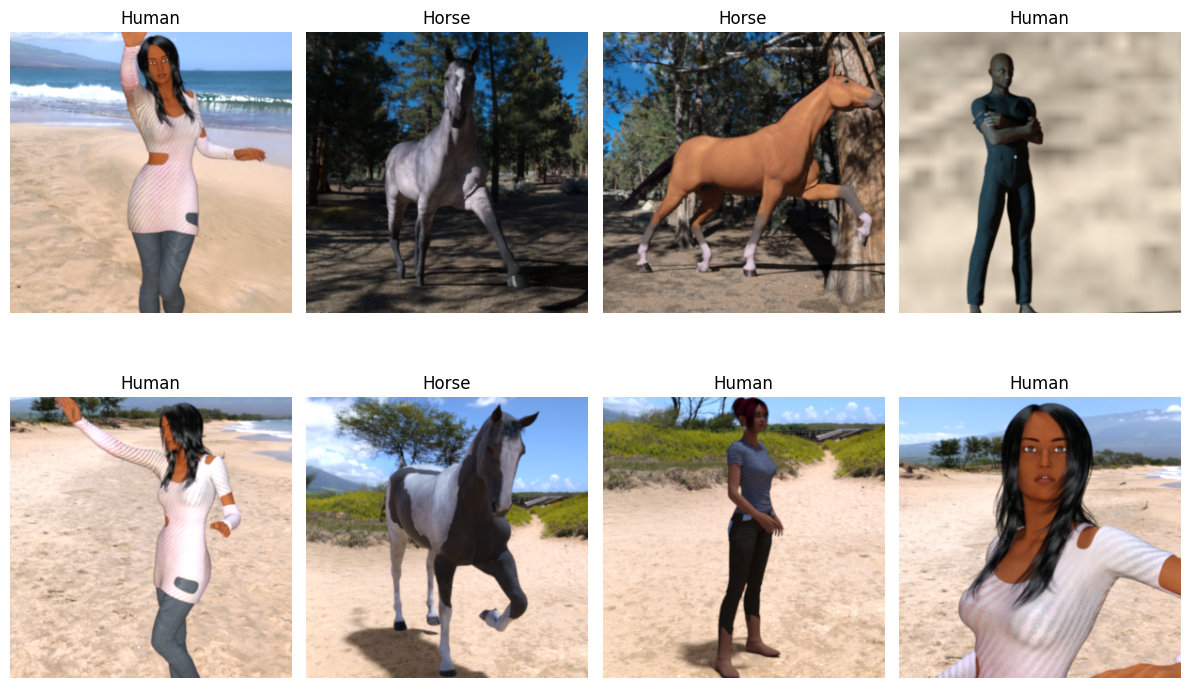

In [24]:
def visualize_samples(dataset, num_samples=8):
    """
    Display sample images from the dataset to understand the data.
    """
    plt.figure(figsize=(12, 8))
    
    # Take one batch from dataset
    for images, labels in dataset.take(1):
        for i in range(min(num_samples, len(images))):
            plt.subplot(2, 4, i + 1)
            plt.imshow(images[i].numpy())
            
            # Convert binary label to class name
            class_name = "Human" if labels[i].numpy() == 1 else "Horse"
            plt.title(f'{class_name}')
            plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Visualize samples
print("=== SAMPLE IMAGES ===")
visualize_samples(train_dataset_final)

## 5. ConvNet Architecture for Complex Images

Building a CNN that can handle 300×300 RGB images requires careful architecture design. The model progressively reduces spatial dimensions while increasing feature depth.

**Architecture Progression:**
- **Input**: 300×300×3 = 270,000 values
- **After convolutions**: 35×35×64 = 78,400 values  
- **Compression ratio**: 3.4× reduction


In [39]:
def create_complex_cnn(input_shape=(300, 300, 3), num_classes=1):
    """
    Creates a CNN architecture designed for complex image classification.
    Uses progressive feature extraction with increasing filter depth.
    """
    
    model = tf.keras.models.Sequential([
        # Input layer
        tf.keras.layers.Input(shape=input_shape),

        # first convolutional block
        tf.keras.layers.Conv2D(16, (3,3), activation='relu'), # 298x298x16
        tf.keras.layers.MaxPooling2D(2,2), # 149x149x16

        # Second convolutional block  
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),  # 147×147×32
        tf.keras.layers.MaxPooling2D(2, 2),                     # 73×73×32
        
        # Third convolutional block
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),  # 71×71×64
        tf.keras.layers.MaxPooling2D(2, 2),                     # 35×35×64
        
        # Fourth convolutional block (for deeper learning)
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),  # 33×33×64
        tf.keras.layers.MaxPooling2D(2, 2),                     # 16×16×64
        
        # Fifth convolutional block (for finest features)
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),  # 14×14×64
        tf.keras.layers.MaxPooling2D(2, 2),                     # 7×7×64


        # flatten for dense layers
        tf.keras.layers.Flatten(), #3,136 features

        # dense layers for classification
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='sigmoid') # binary output
    ])

    return model

# create the model
model = create_complex_cnn()
model.summary()

print("\n=== MODEL ARCHITECTURE ANALYSIS ===")
print(f"Total parameters: {model.count_params():,}")
print("Progressive feature extraction: 16 → 32 → 64 → 64 → 64 filters")
print("Spatial reduction: 300×300 → 149×149 → 73×73 → 35×35 → 16×16 → 7×7")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 298, 298, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 149, 149, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 147, 147, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 73, 73, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 71, 71, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 33, 33, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     1,606,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,704,097 (6.50 MB)

 Trainable params: 1,704,097 (6.50 MB)

 Non-trainable params: 0 (0.00 B)


=== MODEL ARCHITECTURE ANALYSIS ===
Total parameters: 1,704,097
Progressive feature extraction: 16 → 32 → 64 → 64 → 64 filters
Spatial reduction: 300×300 → 149×149 → 73×73 → 35×35 → 16×16 → 7×7


## 6. Model Compilation and Optimization

Choosing the right loss function, optimizer, and metrics is crucial for effective training. For binary classification, we use specific configurations.

**Binary Crossentropy Loss:**
$$L = -\frac{1}{N}\sum_{i=1}^{N} [y_i \log(\hat{y}_i) + (1-y_i) \log(1-\hat{y}_i)]$$


In [26]:
def compile_model(model, learning_rate=0.001):
    """
    Compiles the model with appropriate loss function and optimizer
    for binary image classification.
    """
    
    model.compile(
        loss='binary_crossentropy', # optimal for binary classification
        optimizer=tf.keras.optimizers.RMSprop
        (learning_rate=learning_rate), # adaptive learning rate
        metrics=['accuracy']  # track classification accuracy
    )

    print("=== MODEL COMPILATION ===")
    print(f"Loss function: Binary Crossentropy")
    print(f"Optimizer: RMSprop (learning_rate={learning_rate})")
    print(f"Metrics: Accuracy")
    
    return model

model = compile_model(model)

=== MODEL COMPILATION ===
Loss function: Binary Crossentropy
Optimizer: RMSprop (learning_rate=0.001)
Metrics: Accuracy


## 7. Training with Validation Monitoring

Training with validation data provides real-time feedback about model generalization and helps detect overfitting.

**Overfitting Detection:**
- **Training accuracy >> Validation accuracy** → Overfitting
- **Both accuracies similar** → Good generalization


In [ ]:
def train_with_validation(model, train_dataset, val_dataset, epochs=15):
    """
    Trains the model with validation monitoring to track generalization.
    """
    
    # define callbacks for training control
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        )
    ]

    print("=== TRAINING STARTED ===")
    print(f"Epochs: {epochs}")
    print("Monitoring validation accuracy for overfitting...")
    
    # Train the model
    history = model.fit(
        train_dataset,
        epochs=epochs,
        validation_data=val_dataset,
        callbacks=callbacks,
        verbose=2
    )
    
    print("=== TRAINING COMPLETED ===")
    return history

# Train the model
history = train_with_validation(model, train_dataset_final, validation_dataset_final)

=== TRAINING STARTED ===
Epochs: 5
Monitoring validation accuracy for overfitting...
Epoch 1/5
33/33 - 14s - 436ms/step - accuracy: 0.5862 - loss: 0.7241 - val_accuracy: 0.5078 - val_loss: 0.6547 - learning_rate: 1.0000e-03
Epoch 2/5
33/33 - 12s - 370ms/step - accuracy: 0.8160 - loss: 0.4084 - val_accuracy: 0.6680 - val_loss: 2.4695 - learning_rate: 1.0000e-03
Epoch 3/5
33/33 - 13s - 395ms/step - accuracy: 0.9338 - loss: 0.1765 - val_accuracy: 0.8672 - val_loss: 1.0574 - learning_rate: 1.0000e-03
Epoch 4/5
33/33 - 13s - 402ms/step - accuracy: 0.9747 - loss: 0.0769 - val_accuracy: 0.8711 - val_loss: 0.6290 - learning_rate: 1.0000e-03
Epoch 5/5
33/33 - 13s - 389ms/step - accuracy: 0.9766 - loss: 0.1004 - val_accuracy: 0.8281 - val_loss: 1.3317 - learning_rate: 1.0000e-03
Restoring model weights from the end of the best epoch: 4.
=== TRAINING COMPLETED ===


## 8. Training Progress Visualization

Visualizing training and validation curves helps understand model behavior and detect overfitting patterns.


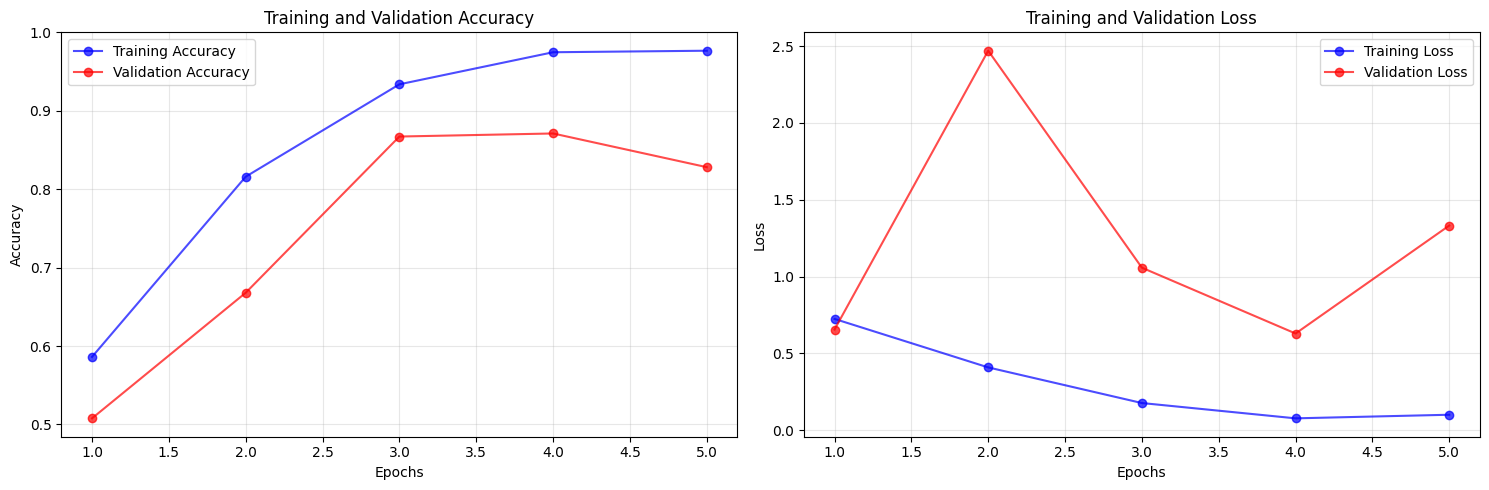

=== FINAL TRAINING METRICS ===
Final Training Accuracy: 0.9766
Final Validation Accuracy: 0.8281
Generalization Gap: 0.1485
⚠️  WARNING: Large generalization gap detected - possible overfitting


In [28]:
def plot_training_history(history):
    """
    Creates comprehensive plots of training and validation metrics
    to analyze model performance and detect overfitting.
    """
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot accuracy curves
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    epochs = range(1, len(acc) + 1)
    
    ax1.plot(epochs, acc, 'bo-', label='Training Accuracy', alpha=0.7)
    ax1.plot(epochs, val_acc, 'ro-', label='Validation Accuracy', alpha=0.7)
    ax1.set_title('Training and Validation Accuracy')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot loss curves
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    ax2.plot(epochs, loss, 'bo-', label='Training Loss', alpha=0.7)
    ax2.plot(epochs, val_loss, 'ro-', label='Validation Loss', alpha=0.7)
    ax2.set_title('Training and Validation Loss')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print final metrics
    print("=== FINAL TRAINING METRICS ===")
    print(f"Final Training Accuracy: {acc[-1]:.4f}")
    print(f"Final Validation Accuracy: {val_acc[-1]:.4f}")
    print(f"Generalization Gap: {abs(acc[-1] - val_acc[-1]):.4f}")
    
    if abs(acc[-1] - val_acc[-1]) > 0.1:
        print("⚠️  WARNING: Large generalization gap detected - possible overfitting")
    else:
        print("✅ Good generalization - model is learning well")

# Plot training history
plot_training_history(history)

## 9. Real-World Testing and Prediction

Testing the model on new images demonstrates real-world performance and reveals failure modes.


In [31]:
def create_prediction_interface():
    """
    Creates an interactive interface for testing the model on uploaded images.
    """
    
    def predict_image(image_path, model, target_size=(300, 300)):
        """
        Predicts whether an image contains a horse or human.
        """
        # Load and preprocess image
        image = tf.keras.utils.load_img(image_path, target_size=target_size)
        image_array = tf.keras.utils.img_to_array(image)
        image_normalized = image_array / 255.0
        image_batch = np.expand_dims(image_normalized, axis=0)
        
        # Make prediction
        prediction = model.predict(image_batch, verbose=0)[0][0]
        
        # Interpret result
        confidence = max(prediction, 1 - prediction)
        if prediction > 0.5:
            result = f"Human (confidence: {prediction:.3f})"
        else:
            result = f"Horse (confidence: {1-prediction:.3f})"
            
        return result, prediction, confidence
    
    # File upload widget for Jupyter notebooks
    uploader = widgets.FileUpload(
        accept='image/*',
        multiple=True,
        description='Upload Images'
    )
    
    output = widgets.Output()
    
    def handle_upload(change):
        """Handle uploaded files and make predictions."""
        with output:
            output.clear_output()
            for file_info in uploader.value:  # now it's a tuple of dicts
                filename = file_info['name']
                content = file_info['content']
                
                # Save uploaded file temporarily
                with open(filename, 'wb') as f:
                    f.write(content)
                
                # Make prediction
                try:
                    result, pred_value, confidence = predict_image(filename, model)
                    print(f"📸 {filename}: {result}")
                    
                    # Display warning for low confidence
                    if confidence < 0.7:
                        print(f"⚠️  Low confidence prediction - consider manual review")
                        
                except Exception as e:
                    print(f"❌ Error processing {filename}: {str(e)}")
                
                # Clean up temporary file
                if os.path.exists(filename):
                    os.remove(filename)

    uploader.observe(handle_upload, names='value')
    
    display(uploader)
    display(output)
    
    return uploader, output

# Create prediction interface
print("=== REAL-WORLD TESTING INTERFACE ===")
print("Upload images to test the model's performance on new data")
uploader, output = create_prediction_interface()

=== REAL-WORLD TESTING INTERFACE ===
Upload images to test the model's performance on new data


FileUpload(value=(), accept='image/*', description='Upload Images', multiple=True)

Output()

## 10. Image Compression Impact Analysis

Comparing different image resolutions shows the trade-off between training speed and model accuracy.

**Compression Analysis:**
- **300×300**: High detail, slow training, better accuracy
- **150×150**: 4× less data, 3× faster training, slight accuracy loss


In [32]:
def compare_resolutions():
    """
    Creates models with different input resolutions to analyze
    the trade-off between speed and accuracy.
    """
    
    resolutions = [(150, 150), (200, 200), (300, 300)]
    results = {}
    
    for width, height in resolutions:
        print(f"\n=== ANALYZING RESOLUTION {width}×{height} ===")
        
        # Calculate data volume
        pixels_per_image = width * height * 3
        compression_ratio = pixels_per_image / (300 * 300 * 3)
        
        print(f"Pixels per image: {pixels_per_image:,}")
        print(f"Compression ratio: {compression_ratio:.2f}")
        print(f"Expected speedup: {1/compression_ratio:.1f}×")
        
        # Create model architecture adapted for resolution
        if width <= 150:
            layers = 3  # Fewer layers for smaller images
        elif width <= 200:
            layers = 4  # Medium layers
        else:
            layers = 5  # Full layers for high resolution
            
        print(f"Recommended convolutional layers: {layers}")
        
        results[f"{width}×{height}"] = {
            'pixels': pixels_per_image,
            'compression': compression_ratio,
            'layers': layers
        }
    
    return results

# Analyze different resolutions
resolution_analysis = compare_resolutions()

# Create a comparison table
print("\n=== RESOLUTION COMPARISON TABLE ===")
print("Resolution | Pixels    | Compression | Layers | Expected Speed")
print("-----------|-----------|-------------|--------|---------------")
for res, data in resolution_analysis.items():
    speed = f"{1/data['compression']:.1f}×"
    print(f"{res:>10} | {data['pixels']:>9,} | {data['compression']:>10.2f} | {data['layers']:>6} | {speed:>13}")


=== ANALYZING RESOLUTION 150×150 ===
Pixels per image: 67,500
Compression ratio: 0.25
Expected speedup: 4.0×
Recommended convolutional layers: 3

=== ANALYZING RESOLUTION 200×200 ===
Pixels per image: 120,000
Compression ratio: 0.44
Expected speedup: 2.2×
Recommended convolutional layers: 4

=== ANALYZING RESOLUTION 300×300 ===
Pixels per image: 270,000
Compression ratio: 1.00
Expected speedup: 1.0×
Recommended convolutional layers: 5

=== RESOLUTION COMPARISON TABLE ===
Resolution | Pixels    | Compression | Layers | Expected Speed
-----------|-----------|-------------|--------|---------------
   150×150 |    67,500 |       0.25 |      3 |          4.0×
   200×200 |   120,000 |       0.44 |      4 |          2.2×
   300×300 |   270,000 |       1.00 |      5 |          1.0×


## 11. Feature Visualization and Model Interpretation

Understanding what the model learns at each layer provides insights into its decision-making process.

=== FEATURE VISUALIZATION ===
Understanding what the CNN learns at each layer


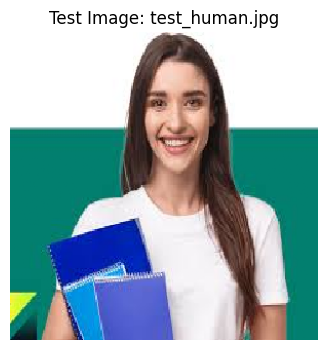

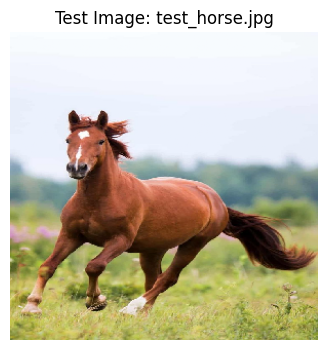

Layer: conv2d_10, Shape: (1, 298, 298, 16)
Layer: conv2d_11, Shape: (1, 147, 147, 32)
Layer: conv2d_12, Shape: (1, 71, 71, 64)
Layer: conv2d_13, Shape: (1, 33, 33, 64)
Layer: conv2d_14, Shape: (1, 14, 14, 64)


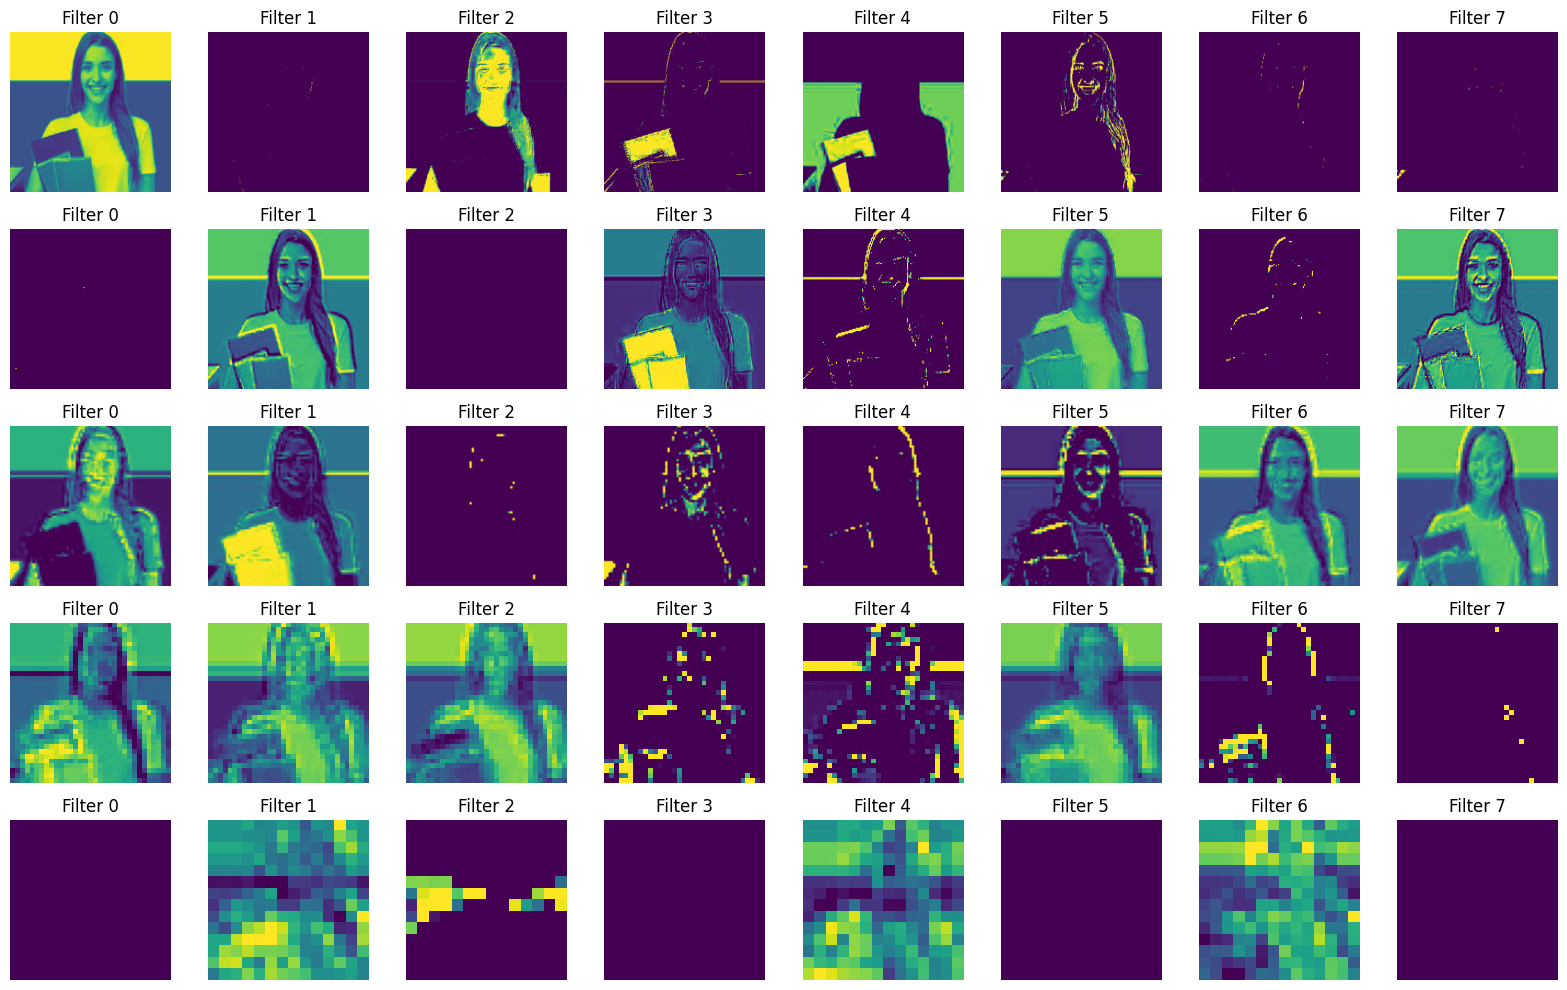

Layer: conv2d_10, Shape: (1, 298, 298, 16)
Layer: conv2d_11, Shape: (1, 147, 147, 32)
Layer: conv2d_12, Shape: (1, 71, 71, 64)
Layer: conv2d_13, Shape: (1, 33, 33, 64)
Layer: conv2d_14, Shape: (1, 14, 14, 64)


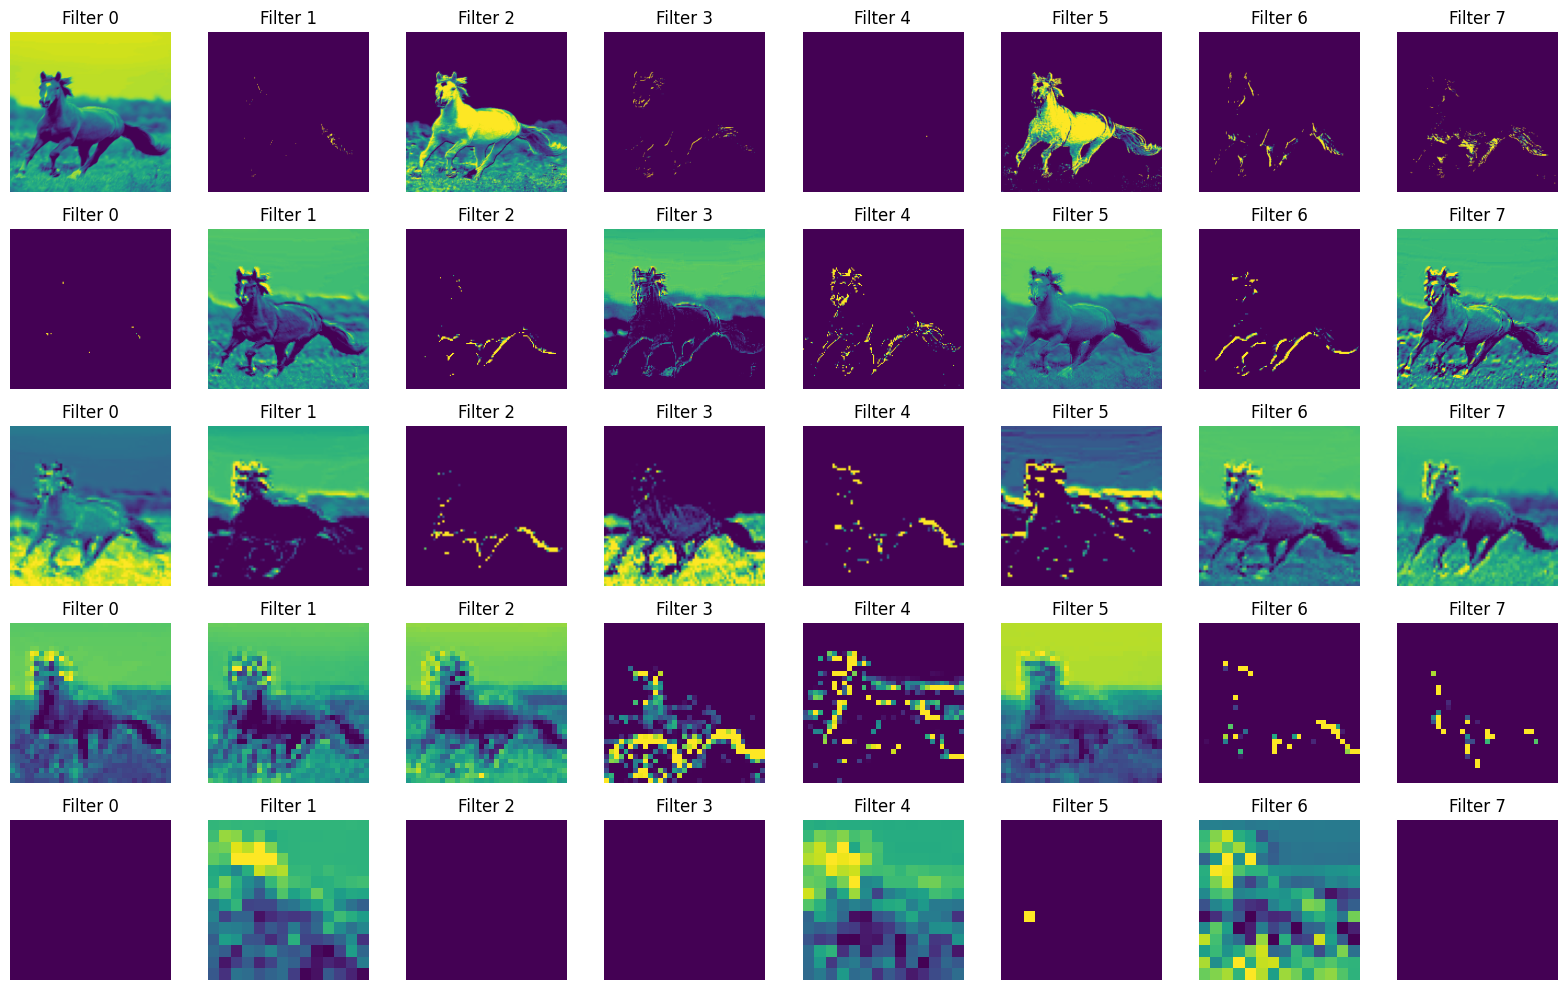

In [41]:
def visualize_feature_maps(model, sample_image, layer_names=None):
    """
    Visualizes what the CNN learns at different layers by showing
    feature maps (activations) for a sample image.
    """
    
    if layer_names is None:
        # Get all convolutional layer names
        layer_names = [layer.name for layer in model.layers 
                      if 'conv2d' in layer.name]
    
    # Create a model that outputs intermediate activations
    outputs = [model.get_layer(name).output for name in layer_names]
    activation_model = tf.keras.Model(inputs=model.inputs, outputs=outputs)
    
    # Get activations for the sample image
    if len(sample_image.shape) == 3:
        sample_image = np.expand_dims(sample_image, axis=0)
    
    activations = activation_model.predict(sample_image, verbose=0)
    
    # Plot feature maps
    fig, axes = plt.subplots(len(layer_names), 8, figsize=(16, 2*len(layer_names)))
    if len(layer_names) == 1:
        axes = axes.reshape(1, -1)
    
    for layer_idx, (layer_name, activation) in enumerate(zip(layer_names, activations)):
        print(f"Layer: {layer_name}, Shape: {activation.shape}")
        
        for i in range(8):  # Show first 8 feature maps
            if i < activation.shape[-1]:
                # Extract feature map
                feature_map = activation[0, :, :, i]
                
                # Normalize for visualization
                feature_map -= feature_map.mean()
                if feature_map.std() > 0:
                    feature_map /= feature_map.std()
                feature_map *= 64
                feature_map += 128
                feature_map = np.clip(feature_map, 0, 255).astype('uint8')
                
                axes[layer_idx, i].imshow(feature_map, cmap='viridis')
                axes[layer_idx, i].set_title(f'Filter {i}')
            
            axes[layer_idx, i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Example feature visualization
print("=== FEATURE VISUALIZATION ===")
print("Understanding what the CNN learns at each layer")

# Load your test image
test_image_path1 = 'test/test_human.jpg'
test_image_path2 = 'test/test_horse.jpg'

sample_image1 = tf.keras.utils.load_img(test_image_path1, target_size=(300, 300))
sample_image1 = tf.keras.utils.img_to_array(sample_image1)
sample_image1 = sample_image1 / 255.0  # Normalize to [0,1]

sample_image2 = tf.keras.utils.load_img(test_image_path2, target_size=(300, 300))
sample_image2 = tf.keras.utils.img_to_array(sample_image2)
sample_image2 = sample_image2 / 255.0  # Normalize to [0,1]


# Show the original image first
plt.figure(figsize=(4, 4))
plt.imshow(sample_image1)
plt.title('Test Image: test_human.jpg')
plt.axis('off')
plt.show()

plt.figure(figsize=(4, 4))
plt.imshow(sample_image2)
plt.title('Test Image: test_horse.jpg')
plt.axis('off')
plt.show()

# Visualize feature maps
visualize_feature_maps(model, sample_image1)
visualize_feature_maps(model, sample_image2)